---
# 0. Project Setup

This notebook implements Task 3 with a reproducible, section-by-section workflow.

In this section we:
- import all dependencies,
- configure device/runtime,
- set robust local/Colab path handling.

Goal: ensure a stable, shared starting point before RL experiments.

In [53]:
import os
import sys
import time
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from IPython.display import display

os.environ["TORCH_COMPILE_DISABLE"] = "1"
%matplotlib inline

# Device selection (same style as task2)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"device: {device}")

# Colab/local setup
USING_COLAB = "google.colab" in sys.modules
if USING_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)


def _find_project_root(marker_file="space_race_env.py", max_depth=7):
    """Find repository root robustly for local and Colab runs."""
    cwd = Path.cwd().resolve()

    # Fast local checks first.
    direct_candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in direct_candidates:
        if candidate.exists() and (candidate / marker_file).exists():
            return candidate

    # Common Colab roots, then bounded recursive search.
    search_roots = [
        Path("/content"),
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/Colab Notebooks"),
    ]

    for base in search_roots:
        if not base.exists():
            continue

        if (base / marker_file).exists():
            return base.resolve()

        for dirpath, dirnames, filenames in os.walk(base):
            rel_depth = len(Path(dirpath).relative_to(base).parts)
            if rel_depth > max_depth:
                dirnames[:] = []
                continue
            if marker_file in filenames:
                return Path(dirpath).resolve()

    raise FileNotFoundError(
        f"Could not locate '{marker_file}'. Place the notebook inside the project "
        "or mount Drive where the project folder exists."
    )


PROJECT_ROOT = _find_project_root(marker_file="space_race_env.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"USING_COLAB: {USING_COLAB}")
print(f"project root: {PROJECT_ROOT}")
print(f"space_race_env.py exists: {(PROJECT_ROOT / 'space_race_env.py').exists()}")

device: cpu
USING_COLAB: False
project root: C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2
space_race_env.py exists: True


---
## 0.1 Constants
This section defines all run-control constants in one place.

In the next code cell we will set:
- FAST mode toggles,
- episode/step budgets,
- shared RL hyperparameters reused from Task 2 baseline style.

Keeping this centralized makes experiments reproducible and easy to tune later.

In [26]:
# Run controls
FAST_RUN = True
LOAD_SAVED_RESULTS = True

# Small budgets for fast validation
N_EPISODES_EXP = 5 if FAST_RUN else 80
N_EPISODES_EVAL = 3 if FAST_RUN else 20
MAX_STEPS_PER_EP = 200 if FAST_RUN else 5000

# Shared RL constants (backbone stays fixed from task2 best config)
N_ACTIONS = 2
BASE_SEED = 42
GAMMA = 0.99
LR = 5e-4
GRAD_CLIP_NORM = 1.0

# Keep these names to mirror task2 style
BEST_GAMMA = GAMMA
BEST_N_FRAMES = 4

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

print(f"FAST_RUN={FAST_RUN}  LOAD_SAVED_RESULTS={LOAD_SAVED_RESULTS}")
print(f"N_EPISODES_EXP={N_EPISODES_EXP}  N_EPISODES_EVAL={N_EPISODES_EVAL}")
print(f"MAX_STEPS_PER_EP={MAX_STEPS_PER_EP}")

FAST_RUN=True  LOAD_SAVED_RESULTS=True
N_EPISODES_EXP=5  N_EPISODES_EVAL=3
MAX_STEPS_PER_EP=200


---
## 0.2 Environment Sanity
Before training, we validate that the environment behaves as expected.

In the next code cell we will:
- instantiate SpaceRaceEnv,
- verify observation shape/dtype/action count,
- run a short random rollout as a smoke test.

This catches integration issues early.

In [54]:
from space_race_env import SpaceRaceEnv

env = SpaceRaceEnv(
    difficulty=0,
    round_time_seconds=60,
    ticks_per_second=10,
    obs_mode="rgb",
    include_semantic_info=True,
)

obs, info = env.reset(seed=BASE_SEED)

print(f"obs shape: {obs.shape}")
print(f"obs dtype: {obs.dtype}")
print(f"action space n: {env.action_space.n}")

# Basic asserts for notebook-level tests
assert obs.shape == (54, 39, 3), f"Unexpected obs shape: {obs.shape}"
assert obs.dtype == np.uint8, f"Unexpected obs dtype: {obs.dtype}"
assert env.action_space.n == 2, f"Unexpected action count: {env.action_space.n}"

# Tiny rollout smoke test
step_rewards = []
for _ in range(20):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    step_rewards.append(float(reward))
    if terminated or truncated:
        break

print(f"rollout steps: {len(step_rewards)}")
print(f"reward sample: {step_rewards[:5]}")
print("[ok] environment sanity checks passed")

obs shape: (54, 39, 3)
obs dtype: uint8
action space n: 2
rollout steps: 20
reward sample: [0.0, 0.02, 0.02, 0.02, 0.02]
[ok] environment sanity checks passed


---
## 0.3 Heuristic Observability And Baselines (Analysis-Only)

Before DQN exploration experiments, we verify what state information is available and benchmark deterministic heuristics.

In the next cells we:
- visualize RGB and semantic channels,
- inspect a centered 5x5 local matrix around the ship,
- benchmark deterministic heuristics in a controlled setting.

Important: semantic info is used for analysis/prototyping only, not as DQN input.

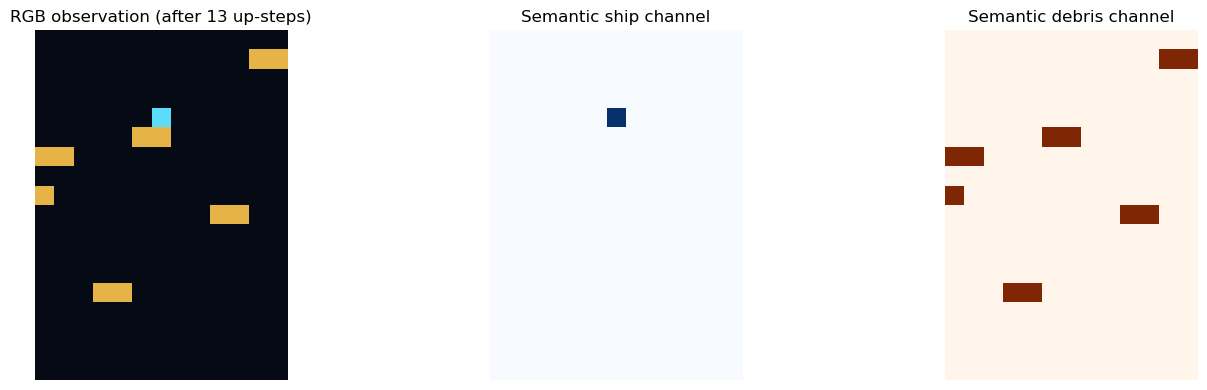

Ship is at row=4, col=6  (row 0=top, row 17=bottom)

5x5 local matrix centred on ship
  Row 0 of matrix = 2 rows AHEAD   (ship travels upward, lower row index)
  Row 2 of matrix = ship position  (0)
  Row 4 of matrix = 2 rows BEHIND  (useful for deciding to retreat)
  Legend:  0=ship  X=debris  -=empty  #=out-of-bounds

- - - - -   <- +2 ahead
- - - - -   <- +1 ahead
- - 0 - -   <- ship   
- X X - -   <- -1 behind
- - - - -   <- -2 behind

[ok] observability visualization and semantic/RGB checks passed


In [28]:
SEMANTIC_COLORS = {
    "empty": np.array([5, 10, 20], dtype=np.uint8),
    "debris": np.array([230, 180, 70], dtype=np.uint8),
    "ship": np.array([90, 220, 250], dtype=np.uint8),
}


def semantic_to_char_grid(semantic_obs):
    ship_map = semantic_obs[:, :, 0] > 0.5
    debris_map = semantic_obs[:, :, 1] > 0.5
    h, w = ship_map.shape
    grid = np.full((h, w), "-", dtype="<U1")
    grid[debris_map] = "X"
    grid[ship_map] = "0"
    return grid, ship_map, debris_map


def centered_local_matrix(char_grid, center_row, center_col, radius=2):
    h, w = char_grid.shape
    out = []
    for r in range(center_row - radius, center_row + radius + 1):
        row_chars = []
        for c in range(center_col - radius, center_col + radius + 1):
            if 0 <= r < h and 0 <= c < w:
                row_chars.append(char_grid[r, c])
            else:
                row_chars.append("#")
        out.append(row_chars)
    return np.array(out)


analysis_env = SpaceRaceEnv(
    difficulty=0,
    round_time_seconds=60,
    ticks_per_second=10,
    obs_mode="rgb",
    include_semantic_info=True,
)
obs, info = analysis_env.reset(seed=BASE_SEED)

# Step up 13 times so the ship reaches a region with richer debris interactions.
for _ in range(13):
    obs, _, _, _, info = analysis_env.step(0)  # action 0 = move up

semantic_obs = info["semantic_obs"]

char_grid, ship_map, debris_map = semantic_to_char_grid(semantic_obs)
ship_pos = np.argwhere(ship_map)
assert ship_pos.shape[0] <= 1, f"Expected <=1 ship, got {ship_pos.shape[0]}"
if ship_pos.shape[0] == 1:
    ship_r, ship_c = map(int, ship_pos[0])
else:
    ship_r, ship_c = analysis_env.start_row, analysis_env.ship_col

# 5x5 window: rows ABOVE ship = ahead, rows BELOW ship = behind.
# radius=2 means we see 2 rows ahead and 2 rows behind the ship's current position.
local_5x5 = centered_local_matrix(char_grid, ship_r, ship_c, radius=2)

# Validate semantic-vs-RGB consistency at semantic grid resolution.
rgb_small = obs.reshape(semantic_obs.shape[0], 3, semantic_obs.shape[1], 3, 3).mean(axis=(1, 3)).astype(np.uint8)
ship_rgb_hits = np.all(rgb_small == SEMANTIC_COLORS["ship"], axis=-1)
debris_rgb_hits = np.all(rgb_small == SEMANTIC_COLORS["debris"], axis=-1)
assert int(ship_rgb_hits.sum()) in (0, 1), "Unexpected number of ship-colored cells"
assert int(debris_rgb_hits.sum()) == int(debris_map.sum()), "Debris count mismatch between semantic and RGB"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(obs)
axes[0].set_title("RGB observation (after 13 up-steps)")
axes[0].axis("off")

axes[1].imshow(ship_map.astype(np.float32), cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Semantic ship channel")
axes[1].axis("off")

axes[2].imshow(debris_map.astype(np.float32), cmap="Oranges", vmin=0, vmax=1)
axes[2].set_title("Semantic debris channel")
axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Ship is at row={ship_r}, col={ship_c}  (row 0=top, row {analysis_env.height-1}=bottom)")
print()
print("5x5 local matrix centred on ship")
print("  Row 0 of matrix = 2 rows AHEAD   (ship travels upward, lower row index)")
print("  Row 2 of matrix = ship position  (0)")
print("  Row 4 of matrix = 2 rows BEHIND  (useful for deciding to retreat)")
print("  Legend:  0=ship  X=debris  -=empty  #=out-of-bounds")
print()
labels = ["<- +2 ahead", "<- +1 ahead", "<- ship   ", "<- -1 behind", "<- -2 behind"]
for row_chars, lbl in zip(local_5x5, labels):
    print(" ".join(row_chars) + "   " + lbl)
print()
print("[ok] observability visualization and semantic/RGB checks passed")

### 0.3.1 Deterministic Heuristic Benchmark (23 Policies)
We benchmark a broad suite of deterministic, semantic-based heuristics as a controlled pre-RL analysis.

Protocol:
- Evaluate with `difficulty=0` for deterministic replay (`return_std` should be ~0 in this setup).
- Use fixed seeds (`BASE_SEED + episode_index`) for strict comparability.
- Use `N_HEURISTIC_STEPS = 100` in FAST mode.

Metrics:
- `return_mean`, `return_std`
- `collisions_mean`, `completed_runs_mean`
- `action0_rate_mean` (fraction of up-actions)
- `action_mix_entropy_mean` (binary entropy of action mix)
- `policy_entropy` (0.0 for deterministic rule policies)

In [29]:
def extract_ship_position(semantic_obs, env_ref):
    ship_map = semantic_obs[:, :, 0] > 0.5
    ship_pos = np.argwhere(ship_map)
    if ship_pos.shape[0] == 1:
        r, c = ship_pos[0]
        return int(r), int(c)
    # During respawn invisibility, semantic ship channel can be empty.
    return int(getattr(env_ref, "ship_row", env_ref.start_row)), int(env_ref.ship_col)


def local_debris_features(semantic_obs, env_ref):
    debris_map = semantic_obs[:, :, 1] > 0.5
    time_ratio = float(semantic_obs[0, 0, 2])
    r, c = extract_ship_position(semantic_obs, env_ref)
    return debris_map, time_ratio, r, c


def has_debris(debris_map, r, c):
    if 0 <= r < debris_map.shape[0] and 0 <= c < debris_map.shape[1]:
        return bool(debris_map[r, c])
    return False


def count_window(debris_map, r0, r1, c0, c1):
    rr0 = max(0, r0)
    rr1 = min(debris_map.shape[0], r1)
    cc0 = max(0, c0)
    cc1 = min(debris_map.shape[1], c1)
    if rr0 >= rr1 or cc0 >= cc1:
        return 0
    return int(np.sum(debris_map[rr0:rr1, cc0:cc1]))


def binary_entropy(p):
    p = float(np.clip(p, 1e-12, 1.0 - 1e-12))
    return float(-(p * np.log2(p) + (1.0 - p) * np.log2(1.0 - p)))


def ensure_state_defaults(state):
    state.setdefault("braking", False)
    state.setdefault("hover_toggle", 0)
    state.setdefault("collision_cooldown", 0)
    state.setdefault("last_collisions", 0)
    state.setdefault("stuck_steps", 0)
    state.setdefault("clear_streak", 0)


def h01_always_up(semantic_obs, env_ref, state):
    _ = semantic_obs, env_ref, state
    return 0


def h02_safe_progress(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    immediate = has_debris(debris_map, r - 1, c)
    one_more = has_debris(debris_map, r - 2, c)
    if r == 0:
        return 1
    if immediate or one_more:
        return 1
    return 0


def h03_deep_lookahead_1x6(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    for k in range(1, 7):
        if has_debris(debris_map, r - k, c):
            return 1
    return 0


def h04_wide_shield_3x3(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    blocked = count_window(debris_map, r - 3, r, c - 1, c + 2) > 0
    return 1 if blocked else 0


def h05_two_step_vault(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    near_blocked = has_debris(debris_map, r - 1, c)
    far_clear = (not has_debris(debris_map, r - 3, c)) and (not has_debris(debris_map, r - 2, c))
    behind_blocked = has_debris(debris_map, r + 1, c)
    if near_blocked and far_clear and not behind_blocked:
        return 0
    return 1 if near_blocked else 0


def h06_left_diagonal_trigger(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    return 1 if has_debris(debris_map, r - 2, c - 1) else 0


def h07_right_diagonal_trigger(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    return 1 if has_debris(debris_map, r - 2, c + 1) else 0


def h08_chevron_radar(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    cells = [(r - 2, c - 1), (r - 1, c), (r - 2, c + 1)]
    return 1 if any(has_debris(debris_map, rr, cc) for rr, cc in cells) else 0


def h09_velocity_intercept(semantic_obs, env_ref, state):
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    prev = state.get("prev_debris", None)
    state["prev_debris"] = debris_map.copy()
    if prev is None:
        return 0

    # Predict horizontal convergence into our lane using one-step temporal shift.
    for rr in (r - 1, r - 2):
        rightward_toward_me = has_debris(prev, rr, c - 2) and has_debris(debris_map, rr, c - 1)
        leftward_toward_me = has_debris(prev, rr, c + 2) and has_debris(debris_map, rr, c + 1)
        if rightward_toward_me or leftward_toward_me or has_debris(debris_map, rr, c):
            return 1
    return 0


def h10_density_guard_5x5(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    density = count_window(debris_map, r - 5, r, c - 2, c + 3)
    return 1 if density > 3 else 0


def h11_micro_gap_opportunist(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    for rr in (r - 1, r - 2):
        if has_debris(debris_map, rr, c - 1) and has_debris(debris_map, rr, c + 1) and (not has_debris(debris_map, rr, c)):
            return 0
    return h02_safe_progress(semantic_obs, env_ref, state)


def h12_hysteresis_brake(semantic_obs, env_ref, state):
    ensure_state_defaults(state)
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)

    trigger = has_debris(debris_map, r - 1, c) or has_debris(debris_map, r - 2, c)
    release_clear = count_window(debris_map, r - 4, r, c, c + 1) == 0

    if state["braking"]:
        if release_clear:
            state["braking"] = False
        else:
            return 1

    if trigger:
        state["braking"] = True
        return 1
    return 0


def h13_bottom_anchor(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    near_bottom = r >= (env_ref.start_row - 1)
    if near_bottom and not has_debris(debris_map, r - 1, c):
        return 0
    return h02_safe_progress(semantic_obs, env_ref, {})


def h14_goal_line_striker(semantic_obs, env_ref, state):
    _ = state
    _, _, r, _ = local_debris_features(semantic_obs, env_ref)
    if r <= 2:
        return 0
    return h03_deep_lookahead_1x6(semantic_obs, env_ref, {})


def h15_midfield_hover(semantic_obs, env_ref, state):
    ensure_state_defaults(state)
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    in_midfield = 6 <= r <= 12
    dense_front = count_window(debris_map, r - 4, r, c - 2, c + 3) >= 4
    if in_midfield and dense_front:
        state["hover_toggle"] = 1 - state["hover_toggle"]
        return state["hover_toggle"]
    return 0


def h16_ahead_behind_escapist(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    ahead_blocked = has_debris(debris_map, r - 1, c)
    behind_clear = not has_debris(debris_map, r + 1, c)
    if ahead_blocked and behind_clear:
        return 1
    return 0


def h17_three_lane_weighted(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)

    def lane_threat(col_offset):
        w = 0
        for k in range(1, 5):
            if has_debris(debris_map, r - k, c + col_offset):
                w += (5 - k)
        return w

    center = lane_threat(0)
    side = 0.5 * (lane_threat(-1) + lane_threat(1))
    return 1 if center > (side + 1.0) else 0


def h18_post_collision_recovery(semantic_obs, env_ref, state):
    ensure_state_defaults(state)
    current_collisions = int(getattr(env_ref, "collisions", 0))
    if current_collisions > state["last_collisions"]:
        state["collision_cooldown"] = 3
    state["last_collisions"] = current_collisions

    if state["collision_cooldown"] > 0:
        state["collision_cooldown"] -= 1
        return 1
    return h02_safe_progress(semantic_obs, env_ref, {})


def h19_time_ratio_finisher(semantic_obs, env_ref, state):
    _ = state
    _, time_ratio, _, _ = local_debris_features(semantic_obs, env_ref)
    if time_ratio < 0.10:
        return 0
    return h04_wide_shield_3x3(semantic_obs, env_ref, {})


def h20_risk_scored_balancer(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)

    risk_up = 2.0 * has_debris(debris_map, r - 1, c) + 1.0 * has_debris(debris_map, r - 2, c)
    risk_down = 1.5 * has_debris(debris_map, r + 1, c) + 0.5 * has_debris(debris_map, r + 2, c)

    if r <= 1:
        return 1
    if r >= env_ref.start_row - 1:
        return 0
    return 0 if (risk_up <= risk_down + 0.25) else 1


def h21_center_lane_guardian(semantic_obs, env_ref, state):
    _ = state
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    deep_center_blocks = sum(has_debris(debris_map, r - k, c) for k in range(1, 8))
    near_center_blocks = sum(has_debris(debris_map, r - k, c) for k in range(1, 3))
    if near_center_blocks > 0:
        return 1
    return 1 if deep_center_blocks >= 3 else 0


def h22_adaptive_window_by_time(semantic_obs, env_ref, state):
    _ = state
    debris_map, time_ratio, r, c = local_debris_features(semantic_obs, env_ref)
    depth = 6 if time_ratio > 0.5 else 3
    width = 2 if time_ratio > 0.5 else 1
    blocked = count_window(debris_map, r - depth, r, c - width, c + width + 1) > (2 if time_ratio > 0.5 else 0)
    return 1 if blocked else 0


def h23_panic_then_push(semantic_obs, env_ref, state):
    ensure_state_defaults(state)
    debris_map, _, r, c = local_debris_features(semantic_obs, env_ref)
    immediate_block = has_debris(debris_map, r - 1, c)

    if immediate_block:
        state["stuck_steps"] += 1
        state["clear_streak"] = 0
    else:
        state["clear_streak"] += 1
        state["stuck_steps"] = max(0, state["stuck_steps"] - 1)

    if state["stuck_steps"] >= 3:
        return 0
    if state["clear_streak"] >= 2:
        return 0
    return 1 if immediate_block else 0


def evaluate_heuristic_policy(policy_fn, n_episodes=20, max_steps=100, base_seed=BASE_SEED, difficulty=0):
    episode_returns = []
    episode_collisions = []
    episode_completed_runs = []
    action0_rates = []
    action_mix_entropies = []

    for ep in range(n_episodes):
        h_env = SpaceRaceEnv(
            difficulty=difficulty,
            round_time_seconds=60,
            ticks_per_second=10,
            obs_mode="rgb",
            include_semantic_info=True,
        )
        _, info = h_env.reset(seed=base_seed + ep)

        total_reward = 0.0
        action_trace = []
        policy_state = {}

        for _ in range(max_steps):
            semantic_obs = info["semantic_obs"]
            action = int(policy_fn(semantic_obs, h_env, policy_state))
            action = 0 if action == 0 else 1
            action_trace.append(action)

            _, reward, terminated, truncated, info = h_env.step(action)
            total_reward += float(reward)
            if terminated or truncated:
                break

        episode_returns.append(total_reward)
        episode_collisions.append(float(info.get("collisions", 0.0)))
        episode_completed_runs.append(float(info.get("completed_runs", 0.0)))

        if action_trace:
            p_up = float(np.mean(np.array(action_trace) == 0))
            action0_rates.append(p_up)
            action_mix_entropies.append(binary_entropy(p_up))
        else:
            action0_rates.append(0.0)
            action_mix_entropies.append(0.0)

    return {
        "return_mean": float(np.mean(episode_returns)),
        "return_std": float(np.std(episode_returns)),
        "collisions_mean": float(np.mean(episode_collisions)),
        "completed_runs_mean": float(np.mean(episode_completed_runs)),
        "action0_rate_mean": float(np.mean(action0_rates)),
        "action_mix_entropy_mean": float(np.mean(action_mix_entropies)),
        "policy_entropy": 0.0,
    }


# difficulty 0/1 are deterministic in this environment; difficulty >=2 is stochastic.
N_HEURISTIC_STEPS = 100
N_HEURISTIC_EPISODES = 5 if FAST_RUN else 20

heuristic_suite = {
    "h01_always_up": h01_always_up,
    "h02_safe_progress": h02_safe_progress,
    "h03_deep_lookahead_1x6": h03_deep_lookahead_1x6,
    "h04_wide_shield_3x3": h04_wide_shield_3x3,
    "h05_two_step_vault": h05_two_step_vault,
    "h06_left_diagonal_trigger": h06_left_diagonal_trigger,
    "h07_right_diagonal_trigger": h07_right_diagonal_trigger,
    "h08_chevron_radar": h08_chevron_radar,
    "h09_velocity_intercept": h09_velocity_intercept,
    "h10_density_guard_5x5": h10_density_guard_5x5,
    "h11_micro_gap_opportunist": h11_micro_gap_opportunist,
    "h12_hysteresis_brake": h12_hysteresis_brake,
    "h13_bottom_anchor": h13_bottom_anchor,
    "h14_goal_line_striker": h14_goal_line_striker,
    "h15_midfield_hover": h15_midfield_hover,
    "h16_ahead_behind_escapist": h16_ahead_behind_escapist,
    "h17_three_lane_weighted": h17_three_lane_weighted,
    "h18_post_collision_recovery": h18_post_collision_recovery,
    "h19_time_ratio_finisher": h19_time_ratio_finisher,
    "h20_risk_scored_balancer": h20_risk_scored_balancer,
    "h21_center_lane_guardian": h21_center_lane_guardian,
    "h22_adaptive_window_by_time": h22_adaptive_window_by_time,
    "h23_panic_then_push": h23_panic_then_push,
}

heur_rows = []
for name, fn in heuristic_suite.items():
    stats = evaluate_heuristic_policy(
        fn,
        n_episodes=N_HEURISTIC_EPISODES,
        max_steps=N_HEURISTIC_STEPS,
        base_seed=BASE_SEED,
        difficulty=0,
    )
    heur_rows.append({"heuristic": name, **stats})

heur_df = pd.DataFrame(heur_rows).sort_values(by="return_mean", ascending=False).reset_index(drop=True)
display(heur_df)

assert len(heur_df) == 23
assert set(heur_df["heuristic"]) == set(heuristic_suite.keys())
assert np.isfinite(heur_df[["return_mean", "collisions_mean", "completed_runs_mean"]].to_numpy()).all(), "Non-finite heuristic metrics"
print(
    f"[ok] 23 deterministic heuristics benchmarked "
    f"(difficulty=0, episodes={N_HEURISTIC_EPISODES}, steps/episode={N_HEURISTIC_STEPS})"
)

,heuristic,return_mean,return_std,collisions_mean,completed_runs_mean,action0_rate_mean,action_mix_entropy_mean,policy_entropy
0,h17_three_lane_weighted,5.72,0.000000e+00,0.0,4.0,0.90,4.689956e-01,0.0
1,h11_micro_gap_opportunist,5.69,0.000000e+00,0.0,4.0,0.89,4.999160e-01,0.0
2,h21_center_lane_guardian,5.69,0.000000e+00,0.0,4.0,0.89,4.999160e-01,0.0
3,h18_post_collision_recovery,5.69,0.000000e+00,0.0,4.0,0.89,4.999160e-01,0.0
4,h02_safe_progress,5.69,0.000000e+00,0.0,4.0,0.89,4.999160e-01,0.0
5,h09_velocity_intercept,5.69,0.000000e+00,0.0,4.0,0.89,4.999160e-01,0.0
6,h12_hysteresis_brake,5.66,0.000000e+00,0.0,4.0,0.88,5.293609e-01,0.0
7,h22_adaptive_window_by_time,5.21,0.000000e+00,1.0,4.0,0.85,6.098403e-01,0.0
8,h16_ahead_behind_escapist,4.98,0.000000e+00,2.0,4.0,0.92,4.021792e-01,0.0
9,h23_panic_then_push,4.98,0.000000e+00,2.0,4.0,0.92,4.021792e-01,0.0


[ok] 23 deterministic heuristics benchmarked (difficulty=0, episodes=5, steps/episode=100)


In [30]:
summary_cols = [
    "heuristic",
    "return_mean",
    "return_std",
    "collisions_mean",
    "completed_runs_mean",
    "action0_rate_mean",
    "action_mix_entropy_mean",
]

print("Top 8 heuristics by return_mean")
display(heur_df[summary_cols].head(8))

print("Bottom 5 heuristics by return_mean")
display(heur_df[summary_cols].tail(5))

print("Determinism check (all return_std should be 0.0 for difficulty=0):")
print(heur_df[["heuristic", "return_std"]].sort_values("return_std", ascending=False).head(5))

Top 8 heuristics by return_mean


,heuristic,return_mean,return_std,collisions_mean,completed_runs_mean,action0_rate_mean,action_mix_entropy_mean
0,h17_three_lane_weighted,5.72,0.0,0.0,4.0,0.90,0.468996
1,h11_micro_gap_opportunist,5.69,0.0,0.0,4.0,0.89,0.499916
2,h21_center_lane_guardian,5.69,0.0,0.0,4.0,0.89,0.499916
3,h18_post_collision_recovery,5.69,0.0,0.0,4.0,0.89,0.499916
4,h02_safe_progress,5.69,0.0,0.0,4.0,0.89,0.499916
5,h09_velocity_intercept,5.69,0.0,0.0,4.0,0.89,0.499916
6,h12_hysteresis_brake,5.66,0.0,0.0,4.0,0.88,0.529361
7,h22_adaptive_window_by_time,5.21,0.0,1.0,4.0,0.85,0.609840


Bottom 5 heuristics by return_mean


,heuristic,return_mean,return_std,collisions_mean,completed_runs_mean,action0_rate_mean,action_mix_entropy_mean
18,h15_midfield_hover,2.54,0.0,3.0,2.0,0.99,0.080793
19,h06_left_diagonal_trigger,2.49,0.0,3.0,2.0,0.96,0.242292
20,h08_chevron_radar,1.67,0.0,2.0,1.0,0.87,0.557438
21,h20_risk_scored_balancer,0.09,0.0,3.0,0.0,0.82,0.680077
22,h07_right_diagonal_trigger,-0.62,0.0,5.0,0.0,0.99,0.080793


Determinism check (all return_std should be 0.0 for difficulty=0):
                   heuristic    return_std
14        h05_two_step_vault  4.440892e-16
0    h17_three_lane_weighted  0.000000e+00
12         h13_bottom_anchor  0.000000e+00
21  h20_risk_scored_balancer  0.000000e+00
20         h08_chevron_radar  0.000000e+00


### 0.3.2 Critical Note: Replay Warm-Start From Heuristics
Warm-starting replay with heuristic trajectories can improve early stability, but it can also bias state-action coverage.

Recommended protocol (if tested later in Task 3):
- keep a no-warm-start baseline,
- run fixed warm-start sizes (e.g., 1k, 5k, 10k transitions),
- keep seeds and training budget identical across arms,
- report both early learning speed and final performance.

---
# 1. Results Tracker

This section defines a lightweight JSON tracker for experiment persistence.

In the next code cell we:
- load prior runs (optional),
- validate summary schema before saving,
- render quick table views for analysis.

Goal: make experiments resumable and comparisons consistent.

In [31]:
RESULTS_FILE = Path("task3_results.json")

# Load existing results (if requested) so we can continue previous experiments.
if LOAD_SAVED_RESULTS and RESULTS_FILE.exists():
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        all_results = json.load(f)
    print(f"loaded {len(all_results)} saved results from {RESULTS_FILE.resolve()}")
else:
    all_results = {}
    if LOAD_SAVED_RESULTS:
        print(f"[!] LOAD_SAVED_RESULTS=True but {RESULTS_FILE} not found, starting fresh")


def save_result(key, summary_dict):
    # Validate schema so every run summary stays consistent.
    required_keys = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
    for k in required_keys:
        assert k in summary_dict, f"Missing key in summary_dict: {k}"

    all_results[key] = summary_dict
    with open(RESULTS_FILE, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2)


def show_results_table():
    # Return a DataFrame view of all stored runs, sorted by score.
    if not all_results:
        print("No results to display yet.")
        return None

    df = pd.DataFrame.from_dict(all_results, orient="index")
    df.index.name = "run_id"
    if "score_mean" in df.columns:
        df = df.sort_values(by="score_mean", ascending=False)
    display(df)
    return df

print(f"results tracker ready: {RESULTS_FILE.resolve()}")
_ = show_results_table()

loaded 8 saved results from C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2\tasks\task3_results.json
results tracker ready: C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2\tasks\task3_results.json


,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
eps_eps_exp_seed42,epsilon,eps_exp,42,0.060,0.140,0.006779,160,6.590002
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.085,0.075,0.008147,160,6.744216
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.125,0.025,0.009872,160,7.640373
boltz_temp_exp_seed42,boltzmann,temp_exp,42,-0.160,0.250,0.003314,160,7.017009
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.165,0.035,0.002024,160,6.474549
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.290,0.170,0.005261,160,7.098470
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.320,0.050,0.004507,160,6.327260
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.355,0.135,-0.001813,160,6.198993


---
## 1.1 Local Tests For Tracker
We now run a tiny self-test to verify tracker reliability.

In the next code cell we will insert one dummy run, assert that it is saved correctly, display it, and then clean it up.

In [32]:
# Tracker smoke test with one dummy row
_dummy_key = "smoke_test_run"
_dummy_summary = {
    "strategy": "epsilon",
    "config": "linear_eps_smoke",
    "seed": BASE_SEED,
    "score_mean": 0.5,
    "score_std": 0.1,
    "q_mean": 0.2,
    "train_steps": 100,
    "wall_clock_sec": 1.2,
}

save_result(_dummy_key, _dummy_summary)

assert _dummy_key in all_results, "dummy key was not stored"
assert RESULTS_FILE.exists(), "results file was not written"

_df = show_results_table()
assert _df is not None and len(_df) >= 1, "results table did not render"

# Cleanup so smoke data does not pollute real experiments
all_results.pop(_dummy_key, None)
with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print("[ok] tracker smoke test passed and cleaned")

,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
smoke_test_run,epsilon,linear_eps_smoke,42,0.500,0.100,0.200000,100,1.200000
eps_eps_exp_seed42,epsilon,eps_exp,42,0.060,0.140,0.006779,160,6.590002
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.085,0.075,0.008147,160,6.744216
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.125,0.025,0.009872,160,7.640373
boltz_temp_exp_seed42,boltzmann,temp_exp,42,-0.160,0.250,0.003314,160,7.017009
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.165,0.035,0.002024,160,6.474549
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.290,0.170,0.005261,160,7.098470
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.320,0.050,0.004507,160,6.327260
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.355,0.135,-0.001813,160,6.198993


[ok] tracker smoke test passed and cleaned


---
# 2. Exploration Setup

This section builds the shared exploration and DQN components used in Task 3.

In the next cells we:
- define epsilon/temperature schedules,
- implement action-selection helpers,
- implement shared DQN backbone and training utilities,
- run local sanity checks before larger experiment grids.

---
## 2.1 Schedule Functions
We define multiple schedule families to control exploration over time.

In the next code cell, each function maps global training step -> control value (epsilon or temperature).

In [33]:
def epsilon_linear(step_idx, eps_start=1.0, eps_end=0.05, total_steps=50_000):
    ratio = min(max(step_idx / max(total_steps, 1), 0.0), 1.0)
    return eps_start + (eps_end - eps_start) * ratio


def epsilon_exp(step_idx, eps_start=1.0, eps_end=0.05, decay_steps=15_000):
    val = eps_end + (eps_start - eps_end) * np.exp(-step_idx / max(decay_steps, 1))
    return float(max(eps_end, min(eps_start, val)))


def epsilon_step(step_idx, eps_start=1.0, eps_end=0.05, step_size=10_000, decay=0.5):
    n = step_idx // max(step_size, 1)
    val = eps_start * (decay ** n)
    return float(max(eps_end, min(eps_start, val)))


def temp_linear(step_idx, t_start=1.5, t_end=0.05, total_steps=50_000):
    ratio = min(max(step_idx / max(total_steps, 1), 0.0), 1.0)
    return t_start + (t_end - t_start) * ratio


def temp_exp(step_idx, t_start=1.5, t_end=0.05, decay_steps=15_000):
    val = t_end + (t_start - t_end) * np.exp(-step_idx / max(decay_steps, 1))
    return float(max(t_end, min(t_start, val)))


def temp_constant(step_idx, t_const=0.35):
    _ = step_idx
    return float(max(t_const, 1e-6))


def build_schedule_curve(fn, n_points=100, max_step=50_000):
    xs = np.linspace(0, max_step, n_points).astype(int)
    ys = np.array([fn(int(s)) for s in xs], dtype=np.float32)
    return xs, ys

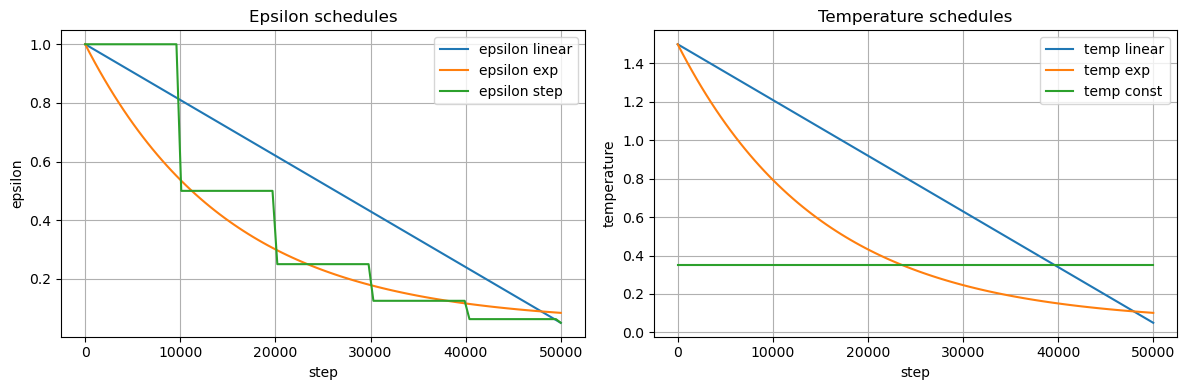

[ok] schedule curves and bounds look valid


In [34]:
# Plot schedule shapes (fast visual sanity)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x, y1 = build_schedule_curve(lambda s: epsilon_linear(s))
_, y2 = build_schedule_curve(lambda s: epsilon_exp(s))
_, y3 = build_schedule_curve(lambda s: epsilon_step(s))
axes[0].plot(x, y1, label="epsilon linear")
axes[0].plot(x, y2, label="epsilon exp")
axes[0].plot(x, y3, label="epsilon step")
axes[0].set_title("Epsilon schedules")
axes[0].set_xlabel("step")
axes[0].set_ylabel("epsilon")
axes[0].grid(True)
axes[0].legend()

x, t1 = build_schedule_curve(lambda s: temp_linear(s))
_, t2 = build_schedule_curve(lambda s: temp_exp(s))
_, t3 = build_schedule_curve(lambda s: temp_constant(s, 0.35))
axes[1].plot(x, t1, label="temp linear")
axes[1].plot(x, t2, label="temp exp")
axes[1].plot(x, t3, label="temp const")
axes[1].set_title("Temperature schedules")
axes[1].set_xlabel("step")
axes[1].set_ylabel("temperature")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Quick numeric checks
assert 0.0 <= float(y1.min()) <= 1.0 and 0.0 <= float(y1.max()) <= 1.0
assert float(t1.min()) > 0.0 and float(t2.min()) > 0.0 and float(t3.min()) > 0.0
print("[ok] schedule curves and bounds look valid")

---
## 2.2 Action Selection Helpers
We now convert Q-values into sampled actions.

In the next code cell we implement:
- epsilon-greedy policy,
- numerically stable Boltzmann policy,
- helper that samples actions from each policy.

In [35]:
def select_action_epsilon_greedy(q_values, epsilon, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))
    return int(np.argmax(q_values))


def boltzmann_probs(q_values, temperature, small_eps=1e-6):
    # Handle torch tensors and keep numeric safety for softmax.
    if isinstance(q_values, torch.Tensor):
        q_values = q_values.detach().cpu().numpy()

    q = np.asarray(q_values, dtype=np.float64)
    temp = max(float(temperature), float(small_eps))

    # Log-sum-exp style stabilization: subtract max before exp.
    scaled_q = q / temp
    stable_q = scaled_q - np.max(scaled_q)

    exp_q = np.exp(stable_q)
    probs = exp_q / np.sum(exp_q)

    # Re-normalize to mitigate tiny floating-point drift.
    probs = probs / np.sum(probs)

    assert np.all(np.isfinite(probs)), "Non-finite probabilities"
    assert abs(np.sum(probs) - 1.0) < 1e-6, f"Probabilities do not sum to 1: {np.sum(probs)}"
    return probs


def select_action_boltzmann(q_values, temperature, rng=None, small_eps=1e-6):
    rng = np.random.default_rng() if rng is None else rng
    probs = boltzmann_probs(q_values, temperature=temperature, small_eps=small_eps)
    return int(rng.choice(len(probs), p=probs))

In [36]:
# Local sanity tests for action selectors
rng = np.random.default_rng(BASE_SEED)
q_test = np.array([0.1, 0.8], dtype=np.float32)

# Epsilon tests
assert select_action_epsilon_greedy(q_test, epsilon=0.0, rng=rng) == 1
samples_eps = [select_action_epsilon_greedy(q_test, epsilon=1.0, rng=rng) for _ in range(200)]
assert set(samples_eps).issubset({0, 1}) and len(set(samples_eps)) == 2

# Boltzmann probability tests
p_hi = boltzmann_probs(q_test, temperature=5.0)
p_lo = boltzmann_probs(q_test, temperature=0.05)
assert p_hi[0] > 0.30 and p_hi[1] < 0.70, f"High-T should be more uniform: {p_hi}"
assert p_lo[1] > 0.95, f"Low-T should be near-greedy: {p_lo}"

samples_boltz = [select_action_boltzmann(q_test, temperature=0.5, rng=rng) for _ in range(500)]
assert set(samples_boltz).issubset({0, 1})

print(f"high-T probs: {p_hi}")
print(f"low-T probs:  {p_lo}")
print("[ok] action selection tests passed")

high-T probs: [0.46505705 0.53494295]
low-T probs:  [8.31527854e-07 9.99999168e-01]
[ok] action selection tests passed


In [37]:
print("=== Exploration validation harness ===")

rng = np.random.default_rng(BASE_SEED)
mock_q_values = np.array([12.5, -3.2], dtype=np.float64)

# Test 1: epsilon boundaries
eps0 = [select_action_epsilon_greedy(mock_q_values, epsilon=0.0, rng=rng) for _ in range(100)]
assert all(a == 0 for a in eps0), "epsilon=0 should always be greedy"

eps1 = [select_action_epsilon_greedy(mock_q_values, epsilon=1.0, rng=rng) for _ in range(500)]
count0 = eps1.count(0)
assert 180 <= count0 <= 320, f"epsilon=1 distribution out of bounds: {count0}/500"
print("[ok] epsilon boundary checks")

# Test 2: Boltzmann temperature extremes
low_t = [select_action_boltzmann(mock_q_values, temperature=1e-5, rng=rng) for _ in range(100)]
assert all(a == 0 for a in low_t), "near-zero temperature should be near-greedy"

high_t = [select_action_boltzmann(mock_q_values, temperature=1e5, rng=rng) for _ in range(1000)]
count0_high = high_t.count(0)
assert 400 <= count0_high <= 600, f"high-temperature distribution out of bounds: {count0_high}/1000"
print("[ok] Boltzmann extreme-temperature checks")

# Test 3: Numerical safety under huge-magnitude Q-values
extreme_q = np.array([85000.0, -120000.0], dtype=np.float64)
act = select_action_boltzmann(extreme_q, temperature=1.0, rng=rng)
assert act == 0, "unexpected action under extreme numerical test"
print("[ok] large-Q numerical safety check")

# Test 4: Deterministic evaluation path policy
def _eval_argmax_step(q_vals):
    return int(np.argmax(q_vals))

eval_actions = [_eval_argmax_step(mock_q_values) for _ in range(50)]
assert all(a == 0 for a in eval_actions), "evaluation policy must be deterministic argmax"
print("[ok] deterministic evaluation policy check")

print("[ok] all exploration component checks passed")

=== Exploration validation harness ===
[ok] epsilon boundary checks
[ok] Boltzmann extreme-temperature checks
[ok] large-Q numerical safety check
[ok] deterministic evaluation policy check
[ok] all exploration component checks passed


### 2.2.1 Local Validation Harness (Compact)

This cell runs strict boundary and stability checks for both exploration strategies before full experiments.

---
## 2.3 Backbone Components (Task 2 Style)
This is the shared DQN backbone reused across both strategies.

In the next cells we implement:
- observation preprocessing,
- convolutional DQN,
- replay buffer,
- one optimization step,
- train/eval helper loops.

Important: strategy changes only affect action selection, not the backbone.

In [38]:
from collections import deque


def preprocess_obs(obs):
    # (H, W, C) uint8 -> (1, C, H, W) float32 in [0, 1]
    obs_t = torch.tensor(obs.astype(np.float32) / 255.0, device=device)
    if obs_t.ndim == 3:
        obs_t = obs_t.unsqueeze(0)
    return obs_t.permute(0, 3, 1, 2)


class DQN(nn.Module):
    def __init__(self, n_frames=4, n_actions=2):
        super().__init__()
        in_channels = 3 * n_frames
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        # infer flattened size
        with torch.no_grad():
            x = torch.zeros(1, in_channels, 54, 39)
            flat_dim = int(np.prod(self.conv(x).shape[1:]))

        self.head = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x):
        z = self.conv(x)
        z = z.reshape(z.size(0), -1)
        return self.head(z)


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size=64):
        idx = np.random.choice(len(self.buffer), size=min(batch_size, len(self.buffer)), replace=False)
        batch = [self.buffer[i] for i in idx]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


# Forward-pass sanity test
_test_net = DQN(n_frames=BEST_N_FRAMES, n_actions=N_ACTIONS).to(device)
_test_x = torch.zeros((2, 3 * BEST_N_FRAMES, 54, 39), device=device)
_test_q = _test_net(_test_x)
assert _test_q.shape == (2, N_ACTIONS), f"Unexpected Q shape: {_test_q.shape}"
print("[ok] backbone components initialized")

[ok] backbone components initialized


In [39]:
def build_stacked_obs(first_obs, n_frames):
    # Initial state stack: duplicate the first frame n times.
    return np.concatenate([first_obs.copy() for _ in range(n_frames)], axis=-1)


def update_stacked_obs(prev_stacked_obs, new_obs):
    # Shift stack left by one RGB frame and append newest RGB frame.
    c = 3
    return np.concatenate([prev_stacked_obs[:, :, c:], new_obs.copy()], axis=-1)


def train_step_dqn(q_net, target_net, replay, optimizer, batch_size=64, gamma=0.99, use_huber=True):
    # Skip update until replay has enough samples.
    if len(replay) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay.sample(batch_size=batch_size)

    # Convert sampled arrays to tensors with the expected shapes.
    s = preprocess_obs(states)
    ns = preprocess_obs(next_states)
    a = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
    r = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    d = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    # Standard DQN target: r + gamma * max_a' Q_target(s', a').
    q_sa = q_net(s).gather(1, a)
    with torch.no_grad():
        max_next = target_net(ns).max(1, keepdim=True).values
        target = r + gamma * max_next * (1.0 - d)

    # Huber loss is often more stable than MSE for Q-learning.
    if use_huber:
        loss = F.huber_loss(q_sa, target)
    else:
        loss = F.mse_loss(q_sa, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP_NORM)
    optimizer.step()
    return float(loss.item())


def train_fast_strategy_run(
    strategy_name,
    schedule_fn,
    seed,
    n_episodes=N_EPISODES_EXP,
    max_steps_per_ep=MAX_STEPS_PER_EP,
    n_frames=BEST_N_FRAMES,
    gamma=BEST_GAMMA,
    return_q_net=False,
):
    # Seed all RNGs for reproducible comparisons.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env_local = SpaceRaceEnv(
        difficulty=0,
        round_time_seconds=60,
        ticks_per_second=10,
        obs_mode="rgb",
        include_semantic_info=True,
    )

    # Build online and target networks (Task 2 style DQN setup).
    q_net = DQN(n_frames=n_frames, n_actions=N_ACTIONS).to(device)
    target_net = DQN(n_frames=n_frames, n_actions=N_ACTIONS).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.RMSprop(q_net.parameters(), lr=LR, alpha=0.99, eps=1e-8)
    replay = ReplayBuffer(capacity=10_000)

    step_idx = 0
    reward_hist, loss_hist, q_hist = [], [], []
    schedule_hist, entropy_hist = [], []

    t0 = time.time()
    for ep in range(n_episodes):
        obs, info = env_local.reset(seed=seed + ep)
        state = build_stacked_obs(obs, n_frames=n_frames)

        ep_reward = 0.0
        ep_losses = []
        ep_q_vals = []
        ep_actions = []

        for _ in range(max_steps_per_ep):
            # Compute Q-values from current stacked observation.
            q_values_t = q_net(preprocess_obs(state))[0].detach().cpu().numpy()
            ep_q_vals.append(float(np.max(q_values_t)))

            # Strategy-specific action selection with a shared schedule interface.
            ctrl = float(schedule_fn(step_idx))
            if strategy_name == "epsilon":
                action = select_action_epsilon_greedy(q_values_t, epsilon=ctrl)
                probs = np.array([ctrl / 2.0, ctrl / 2.0])
                probs[np.argmax(q_values_t)] += 1.0 - ctrl
            elif strategy_name == "boltzmann":
                action = select_action_boltzmann(q_values_t, temperature=ctrl)
                probs = boltzmann_probs(q_values_t, temperature=ctrl)
            else:
                raise ValueError(f"Unknown strategy: {strategy_name}")

            # Log exploration entropy to compare policy randomness over time.
            entropy = -np.sum(probs * np.log(np.clip(probs, 1e-8, 1.0)))
            entropy_hist.append(float(entropy))
            schedule_hist.append(ctrl)
            ep_actions.append(int(action))

            next_obs, reward, terminated, truncated, next_info = env_local.step(action)
            done = bool(terminated or truncated)
            next_state = update_stacked_obs(state, next_obs)

            # Store transition then try one gradient update.
            replay.add(state, action, float(reward), next_state, done)
            loss_val = train_step_dqn(q_net, target_net, replay, optimizer, batch_size=64, gamma=gamma, use_huber=True)
            if loss_val is not None:
                ep_losses.append(loss_val)

            # Periodically refresh target network for stability.
            if step_idx % 100 == 0:
                target_net.load_state_dict(q_net.state_dict())

            ep_reward += float(reward)
            state = next_state
            step_idx += 1
            if done:
                break

        reward_hist.append(ep_reward)
        loss_hist.append(float(np.mean(ep_losses)) if ep_losses else np.nan)
        q_hist.append(float(np.mean(ep_q_vals)) if ep_q_vals else np.nan)

    wall = time.time() - t0
    env_local.close()

    # Return both run metrics and optionally the trained network.
    out = {
        "strategy": strategy_name,
        "seed": int(seed),
        "reward_hist": reward_hist,
        "loss_hist": loss_hist,
        "q_hist": q_hist,
        "schedule_hist": schedule_hist,
        "entropy_hist": entropy_hist,
        "score_mean": float(np.nanmean(reward_hist)),
        "score_std": float(np.nanstd(reward_hist)),
        "q_mean": float(np.nanmean(q_hist)),
        "train_steps": int(step_idx),
        "wall_clock_sec": float(wall),
    }
    if return_q_net:
        out["q_net"] = q_net
    return out


def evaluate_deterministic(q_net, seed=BASE_SEED, n_episodes=N_EPISODES_EVAL, n_frames=BEST_N_FRAMES, max_steps_per_ep=MAX_STEPS_PER_EP):
    # Deterministic evaluation: always take argmax action.
    env_eval = SpaceRaceEnv(
        difficulty=0,
        round_time_seconds=60,
        ticks_per_second=10,
        obs_mode="rgb",
        include_semantic_info=False,
    )

    scores = []
    with torch.no_grad():
        for ep in range(n_episodes):
            obs, info = env_eval.reset(seed=seed + 1000 + ep)
            state = build_stacked_obs(obs, n_frames=n_frames)
            total_reward = 0.0

            for _ in range(max_steps_per_ep):
                q_vals = q_net(preprocess_obs(state))[0].detach().cpu().numpy()
                action = int(np.argmax(q_vals))
                next_obs, reward, terminated, truncated, info = env_eval.step(action)
                total_reward += float(reward)
                state = update_stacked_obs(state, next_obs)
                if terminated or truncated:
                    break

            scores.append(total_reward)

    env_eval.close()
    return float(np.mean(scores)), float(np.std(scores))

---
## 2.3.1 FAST Ablation: Heuristic Warm-Start Into DQN

This ablation tests whether top deterministic heuristics help DQN when used to prefill replay.

Arms compared under the same FAST budget:
- no warm-start baseline,
- each top-3 heuristic individually,
- mixed top-3 variants (round-robin, random-per-step, majority vote).

Evaluation:
- train with exploration enabled,
- evaluate deterministically (argmax),
- compare mean performance across seeds.

In [40]:
assert "heur_df" in globals() and "heuristic_suite" in globals(), "Run Section 0.3 heuristic benchmark first"

# Pick top-3 deterministic heuristics by return_mean from section 0.3.
TOP3_HEURISTICS = heur_df.head(3)["heuristic"].tolist()
TOP3_FNS = [heuristic_suite[name] for name in TOP3_HEURISTICS]
print("Top-3 deterministic heuristics:", TOP3_HEURISTICS)


def mixed_top3_round_robin(semantic_obs, env_ref, state):
    idx = int(state.get("mix_idx", 0)) % 3
    state["mix_idx"] = idx + 1
    fn = TOP3_FNS[idx]
    nested = state.setdefault(f"rr_state_{idx}", {})
    return int(fn(semantic_obs, env_ref, nested))


def mixed_top3_random_per_step(semantic_obs, env_ref, state):
    if "rng" not in state:
        state["rng"] = np.random.default_rng(BASE_SEED)
    idx = int(state["rng"].integers(0, 3))
    fn = TOP3_FNS[idx]
    nested = state.setdefault(f"rand_state_{idx}", {})
    return int(fn(semantic_obs, env_ref, nested))


def mixed_top3_majority_vote(semantic_obs, env_ref, state):
    votes = []
    for i, fn in enumerate(TOP3_FNS):
        nested = state.setdefault(f"vote_state_{i}", {})
        votes.append(int(fn(semantic_obs, env_ref, nested)))
    return 1 if (sum(votes) >= 2) else 0


def collect_heuristic_transitions(policy_fn, n_transitions, seed, n_frames=BEST_N_FRAMES):
    ws_env = SpaceRaceEnv(
        difficulty=0,
        round_time_seconds=60,
        ticks_per_second=10,
        obs_mode="rgb",
        include_semantic_info=True,
    )

    transitions = []
    ep_idx = 0
    policy_state = {}

    while len(transitions) < n_transitions:
        obs, info = ws_env.reset(seed=seed + ep_idx)
        state = build_stacked_obs(obs, n_frames=n_frames)
        policy_state.clear()

        for _ in range(MAX_STEPS_PER_EP):
            semantic_obs = info["semantic_obs"]
            action = int(policy_fn(semantic_obs, ws_env, policy_state))
            action = 0 if action == 0 else 1

            next_obs, reward, terminated, truncated, info = ws_env.step(action)
            done = bool(terminated or truncated)
            next_state = update_stacked_obs(state, next_obs)

            transitions.append((state, action, float(reward), next_state, done))
            state = next_state

            if len(transitions) >= n_transitions or done:
                break
        ep_idx += 1

    ws_env.close()
    return transitions


def train_fast_strategy_run_with_warmstart(
    strategy_name,
    schedule_fn,
    seed,
    warmstart_policy_fn=None,
    warmstart_label="none",
    warmstart_n=0,
    n_episodes=N_EPISODES_EXP,
    max_steps_per_ep=MAX_STEPS_PER_EP,
    n_frames=BEST_N_FRAMES,
    gamma=BEST_GAMMA,
    return_q_net=False,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env_local = SpaceRaceEnv(
        difficulty=0,
        round_time_seconds=60,
        ticks_per_second=10,
        obs_mode="rgb",
        include_semantic_info=True,
    )

    q_net = DQN(n_frames=n_frames, n_actions=N_ACTIONS).to(device)
    target_net = DQN(n_frames=n_frames, n_actions=N_ACTIONS).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.RMSprop(q_net.parameters(), lr=LR, alpha=0.99, eps=1e-8)
    replay = ReplayBuffer(capacity=10_000)

    warmstart_added = 0
    if warmstart_policy_fn is not None and warmstart_n > 0:
        ws_transitions = collect_heuristic_transitions(
            warmstart_policy_fn,
            n_transitions=warmstart_n,
            seed=seed + 50_000,
            n_frames=n_frames,
        )
        for s, a, r, ns, d in ws_transitions:
            replay.add(s, a, r, ns, d)
        warmstart_added = len(ws_transitions)

    step_idx = 0
    reward_hist, loss_hist, q_hist = [], [], []
    schedule_hist, entropy_hist = [], []

    t0 = time.time()
    for ep in range(n_episodes):
        obs, info = env_local.reset(seed=seed + ep)
        state = build_stacked_obs(obs, n_frames=n_frames)

        ep_reward = 0.0
        ep_losses = []
        ep_q_vals = []

        for _ in range(max_steps_per_ep):
            q_values_t = q_net(preprocess_obs(state))[0].detach().cpu().numpy()
            ep_q_vals.append(float(np.max(q_values_t)))

            ctrl = float(schedule_fn(step_idx))
            if strategy_name == "epsilon":
                action = select_action_epsilon_greedy(q_values_t, epsilon=ctrl)
                probs = np.array([ctrl / 2.0, ctrl / 2.0], dtype=np.float64)
                probs[np.argmax(q_values_t)] += 1.0 - ctrl
            elif strategy_name == "boltzmann":
                action = select_action_boltzmann(q_values_t, temperature=ctrl)
                probs = boltzmann_probs(q_values_t, temperature=ctrl)
            else:
                raise ValueError(f"Unknown strategy: {strategy_name}")

            entropy = -np.sum(probs * np.log(np.clip(probs, 1e-8, 1.0)))
            entropy_hist.append(float(entropy))
            schedule_hist.append(ctrl)

            next_obs, reward, terminated, truncated, next_info = env_local.step(action)
            done = bool(terminated or truncated)
            next_state = update_stacked_obs(state, next_obs)

            replay.add(state, action, float(reward), next_state, done)
            loss_val = train_step_dqn(
                q_net, target_net, replay, optimizer,
                batch_size=64, gamma=gamma, use_huber=True
            )
            if loss_val is not None:
                ep_losses.append(loss_val)

            if step_idx % 100 == 0:
                target_net.load_state_dict(q_net.state_dict())

            ep_reward += float(reward)
            state = next_state
            info = next_info
            step_idx += 1
            if done:
                break

        reward_hist.append(ep_reward)
        loss_hist.append(float(np.mean(ep_losses)) if ep_losses else np.nan)
        q_hist.append(float(np.mean(ep_q_vals)) if ep_q_vals else np.nan)

    wall = time.time() - t0
    env_local.close()

    out = {
        "strategy": strategy_name,
        "seed": int(seed),
        "warmstart_label": warmstart_label,
        "warmstart_added": int(warmstart_added),
        "reward_hist": reward_hist,
        "loss_hist": loss_hist,
        "q_hist": q_hist,
        "schedule_hist": schedule_hist,
        "entropy_hist": entropy_hist,
        "score_mean": float(np.nanmean(reward_hist)),
        "score_std": float(np.nanstd(reward_hist)),
        "q_mean": float(np.nanmean(q_hist)),
        "train_steps": int(step_idx),
        "wall_clock_sec": float(wall),
    }
    if return_q_net:
        out["q_net"] = q_net
    return out


WARMSTART_N_FAST = 400 if FAST_RUN else 2_000
WARMSTART_SEEDS = [BASE_SEED, BASE_SEED + 1]
EPS_SCHEDULE_FAST = lambda s: epsilon_linear(s, eps_start=1.0, eps_end=0.10, total_steps=1_500)

warmstart_arms = [
    {"label": "baseline_no_warmstart", "policy_fn": None},
    {"label": f"single_{TOP3_HEURISTICS[0]}", "policy_fn": TOP3_FNS[0]},
    {"label": f"single_{TOP3_HEURISTICS[1]}", "policy_fn": TOP3_FNS[1]},
    {"label": f"single_{TOP3_HEURISTICS[2]}", "policy_fn": TOP3_FNS[2]},
    {"label": "mix_round_robin", "policy_fn": mixed_top3_round_robin},
    {"label": "mix_random_per_step", "policy_fn": mixed_top3_random_per_step},
    {"label": "mix_majority_vote", "policy_fn": mixed_top3_majority_vote},
]

warm_rows = []
for arm in warmstart_arms:
    for seed in WARMSTART_SEEDS:
        run = train_fast_strategy_run_with_warmstart(
            strategy_name="epsilon",
            schedule_fn=EPS_SCHEDULE_FAST,
            seed=seed,
            warmstart_policy_fn=arm["policy_fn"],
            warmstart_label=arm["label"],
            warmstart_n=(0 if arm["policy_fn"] is None else WARMSTART_N_FAST),
            n_episodes=3 if FAST_RUN else 10,
            max_steps_per_ep=120 if FAST_RUN else 400,
            return_q_net=True,
        )

        eval_mean, eval_std = evaluate_deterministic(
            run["q_net"],
            seed=seed,
            n_episodes=3 if FAST_RUN else 8,
            max_steps_per_ep=120 if FAST_RUN else 400,
        )

        warm_rows.append({
            "arm": arm["label"],
            "seed": int(seed),
            "warmstart_added": int(run["warmstart_added"]),
            "train_score_mean": float(run["score_mean"]),
            "train_score_std": float(run["score_std"]),
            "det_eval_mean": float(eval_mean),
            "det_eval_std": float(eval_std),
            "q_mean": float(run["q_mean"]),
            "train_steps": int(run["train_steps"]),
            "wall_clock_sec": float(run["wall_clock_sec"]),
        })
        print(f"[ok] warmstart arm={arm['label']} seed={seed} done")

warm_df = pd.DataFrame(warm_rows).sort_values(["arm", "seed"]).reset_index(drop=True)
display(warm_df)

warm_agg = (
    warm_df.groupby("arm", as_index=False)
    .agg(
        det_eval_mean_across_seeds=("det_eval_mean", "mean"),
        det_eval_std_across_seeds=("det_eval_mean", "std"),
        train_score_mean_across_seeds=("train_score_mean", "mean"),
        train_score_std_across_seeds=("train_score_mean", "std"),
        wall_clock_mean=("wall_clock_sec", "mean"),
        n_seeds=("seed", "count"),
    )
    .sort_values("det_eval_mean_across_seeds", ascending=False)
    .reset_index(drop=True)
)

print("Warm-start ablation summary (sorted by deterministic eval):")
display(warm_agg)
assert warm_agg["n_seeds"].min() >= 2, "Need at least 2 seeds per arm"
print("[ok] top-3 heuristic warm-start FAST ablation complete")

Top-3 deterministic heuristics: ['h17_three_lane_weighted', 'h11_micro_gap_opportunist', 'h21_center_lane_guardian']
[ok] warmstart arm=baseline_no_warmstart seed=42 done
[ok] warmstart arm=baseline_no_warmstart seed=43 done
[ok] warmstart arm=single_h17_three_lane_weighted seed=42 done
[ok] warmstart arm=single_h17_three_lane_weighted seed=43 done
[ok] warmstart arm=single_h11_micro_gap_opportunist seed=42 done
[ok] warmstart arm=single_h11_micro_gap_opportunist seed=43 done
[ok] warmstart arm=single_h21_center_lane_guardian seed=42 done
[ok] warmstart arm=single_h21_center_lane_guardian seed=43 done
[ok] warmstart arm=mix_round_robin seed=42 done
[ok] warmstart arm=mix_round_robin seed=43 done
[ok] warmstart arm=mix_random_per_step seed=42 done
[ok] warmstart arm=mix_random_per_step seed=43 done
[ok] warmstart arm=mix_majority_vote seed=42 done
[ok] warmstart arm=mix_majority_vote seed=43 done


,arm,seed,warmstart_added,train_score_mean,train_score_std,det_eval_mean,det_eval_std,q_mean,train_steps,wall_clock_sec
0,baseline_no_warmstart,42,0,-0.193333,0.382739,2.53,0.0,0.009810,360,14.710231
1,baseline_no_warmstart,43,0,-0.340000,0.302324,-0.59,0.0,0.009430,360,14.215416
2,mix_majority_vote,42,400,-0.226667,0.122565,3.81,0.0,2.373349,360,23.290526
3,mix_majority_vote,43,400,-0.253333,0.192585,1.16,0.0,1.637730,360,19.860808
4,mix_random_per_step,42,400,-0.150000,0.149889,3.81,0.0,2.176299,360,27.637456
5,mix_random_per_step,43,400,-0.393333,0.302251,-0.31,0.0,1.953626,360,26.197898
6,mix_round_robin,42,400,-0.520000,0.155563,3.81,0.0,2.216109,360,19.614161
7,mix_round_robin,43,400,-0.503333,0.132749,-0.86,0.0,1.948749,360,20.557549
8,single_h11_micro_gap_opportunist,42,400,-0.343333,0.209815,3.81,0.0,2.310653,360,17.166842
9,single_h11_micro_gap_opportunist,43,400,-0.153333,0.237954,0.04,0.0,1.615333,360,18.760799


Warm-start ablation summary (sorted by deterministic eval):


,arm,det_eval_mean_across_seeds,det_eval_std_across_seeds,train_score_mean_across_seeds,train_score_std_across_seeds,wall_clock_mean,n_seeds
0,single_h21_center_lane_guardian,3.810,0.000000,-0.446667,0.113137,19.212899,2
1,mix_majority_vote,2.485,1.873833,-0.240000,0.018856,21.575667,2
2,single_h11_micro_gap_opportunist,1.925,2.665793,-0.248333,0.134350,17.963821,2
3,mix_random_per_step,1.750,2.913280,-0.271667,0.172063,26.917677,2
4,single_h17_three_lane_weighted,1.750,2.913280,-0.101667,0.337054,17.170852,2
5,mix_round_robin,1.475,3.302189,-0.511667,0.011785,20.085855,2
6,baseline_no_warmstart,0.970,2.206173,-0.266667,0.103709,14.462823,2


[ok] top-3 heuristic warm-start FAST ablation complete


---
## 2.4 FAST Smoke Runs

Before full mini-grids, we run one tiny pass per exploration strategy.

Purpose:
- verify training loop stability,
- verify metrics are finite,
- catch runtime issues early at low cost.

In [41]:
# Tiny smoke run: epsilon
run_eps = train_fast_strategy_run(
    strategy_name="epsilon",
    schedule_fn=lambda s: epsilon_linear(s, eps_start=1.0, eps_end=0.1, total_steps=1_000),
    seed=BASE_SEED,
    n_episodes=2 if FAST_RUN else 5,
    max_steps_per_ep=80 if FAST_RUN else 300,
)

print("epsilon smoke summary:")
print({k: run_eps[k] for k in ["score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]})
assert len(run_eps["reward_hist"]) > 0
assert np.isfinite(run_eps["score_mean"])
print("[ok] epsilon smoke run passed")

epsilon smoke summary:
{'score_mean': 0.024999999999999883, 'score_std': 0.12499999999999989, 'q_mean': 0.005938628510921262, 'train_steps': 160, 'wall_clock_sec': 7.410989999771118}
[ok] epsilon smoke run passed


In [42]:
# Tiny smoke run: Boltzmann
run_boltz = train_fast_strategy_run(
    strategy_name="boltzmann",
    schedule_fn=lambda s: temp_exp(s, t_start=1.2, t_end=0.2, decay_steps=1_000),
    seed=BASE_SEED,
    n_episodes=2 if FAST_RUN else 5,
    max_steps_per_ep=80 if FAST_RUN else 300,
)

print("boltzmann smoke summary:")
print({k: run_boltz[k] for k in ["score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]})
assert len(run_boltz["reward_hist"]) > 0
assert np.isfinite(run_boltz["score_mean"])
print("[ok] boltzmann smoke run passed")

boltzmann smoke summary:
{'score_mean': -0.1250000000000001, 'score_std': 0.0049999999999999975, 'q_mean': 0.0028837726975325492, 'train_steps': 160, 'wall_clock_sec': 6.3015313148498535}
[ok] boltzmann smoke run passed


---
# 3. Epsilon-Greedy Mini Grid (FAST)

We run a compact epsilon-only grid to validate experiment orchestration.

In the next code cells we:
- train multiple epsilon schedules,
- repeat with multiple seeds,
- persist summaries to the results tracker.

In [43]:
# Backbone/config uniformity checks before experiment loops
print("Using shared baseline config for both strategy grids:")
print(f"- n_frames: {BEST_N_FRAMES}")
print(f"- gamma: {BEST_GAMMA}")
print(f"- preprocess: preprocess_obs")
print("- target sync: every 100 steps")
print("- replay capacity: 10000")

assert BEST_N_FRAMES == 4, "Task-2 carryover expects n_frames=4"
assert abs(BEST_GAMMA - 0.99) < 1e-12, "Task-2 carryover expects gamma=0.99"

# Quick structural check that preprocessing produces (N,C,H,W) with 3*n_frames channels
_shape_check = preprocess_obs(np.zeros((54, 39, 3 * BEST_N_FRAMES), dtype=np.uint8)).shape
assert _shape_check == (1, 3 * BEST_N_FRAMES, 54, 39), f"Unexpected preprocess shape: {_shape_check}"
print("[ok] baseline uniformity checks passed")

Using shared baseline config for both strategy grids:
- n_frames: 4
- gamma: 0.99
- preprocess: preprocess_obs
- target sync: every 100 steps
- replay capacity: 10000
[ok] baseline uniformity checks passed


In [44]:
# Two seeds are enough for FAST sanity checks; increase in full runs.
SEED_GRID_FAST = [BASE_SEED, BASE_SEED + 1]

# Candidate epsilon schedules to compare.
EPS_CONFIGS_FAST = {
    "eps_linear": lambda s: epsilon_linear(s, eps_start=1.0, eps_end=0.10, total_steps=1_500),
    "eps_exp": lambda s: epsilon_exp(s, eps_start=1.0, eps_end=0.10, decay_steps=700),
}

# Train each config/seed pair and persist a compact summary row.
for cfg_name, cfg_fn in EPS_CONFIGS_FAST.items():
    for seed in SEED_GRID_FAST:
        run = train_fast_strategy_run(
            strategy_name="epsilon",
            schedule_fn=cfg_fn,
            seed=seed,
            n_episodes=2 if FAST_RUN else 8,
            max_steps_per_ep=80 if FAST_RUN else 300,
        )

        run_id = f"eps_{cfg_name}_seed{seed}"
        summary = {
            "strategy": "epsilon",
            "config": cfg_name,
            "seed": seed,
            "score_mean": run["score_mean"],
            "score_std": run["score_std"],
            "q_mean": run["q_mean"],
            "train_steps": run["train_steps"],
            "wall_clock_sec": run["wall_clock_sec"],
        }
        save_result(run_id, summary)
        print(f"[ok] saved {run_id}")

print("[ok] epsilon mini grid finished")

[ok] saved eps_eps_linear_seed42
[ok] saved eps_eps_linear_seed43
[ok] saved eps_eps_exp_seed42
[ok] saved eps_eps_exp_seed43
[ok] epsilon mini grid finished


In [45]:
# Show only epsilon rows in a clean table view.
df_all = show_results_table()
if df_all is None or len(df_all) == 0:
    print("No results saved yet.")
else:
    df_eps = df_all[df_all["strategy"] == "epsilon"].sort_values(["config", "seed"]).reset_index()
    print("Epsilon runs:")
    display(df_eps)

,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.125,0.025,0.009872,160,7.640373
eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
boltz_temp_exp_seed42,boltzmann,temp_exp,42,-0.160,0.250,0.003314,160,7.017009
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.320,0.050,0.004507,160,6.327260
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.355,0.135,-0.001813,160,6.198993


Epsilon runs:


,run_id,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
0,eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
1,eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
2,eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
3,eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266


---
# 4. Boltzmann Mini Grid (FAST)

This mirrors Section 3 while keeping backbone and budget fixed.

Only the exploration strategy changes, enabling a fair epsilon vs Boltzmann comparison.

In [46]:
# Candidate Boltzmann schedules to compare.
BOLTZ_CONFIGS_FAST = {
    "temp_exp": lambda s: temp_exp(s, t_start=1.2, t_end=0.2, decay_steps=700),
    "temp_linear": lambda s: temp_linear(s, t_start=1.2, t_end=0.2, total_steps=1_500),
}

# Same protocol as epsilon cell, only the exploration strategy changes.
for cfg_name, cfg_fn in BOLTZ_CONFIGS_FAST.items():
    for seed in SEED_GRID_FAST:
        run = train_fast_strategy_run(
            strategy_name="boltzmann",
            schedule_fn=cfg_fn,
            seed=seed,
            n_episodes=2 if FAST_RUN else 8,
            max_steps_per_ep=80 if FAST_RUN else 300,
        )

        run_id = f"boltz_{cfg_name}_seed{seed}"
        summary = {
            "strategy": "boltzmann",
            "config": cfg_name,
            "seed": seed,
            "score_mean": run["score_mean"],
            "score_std": run["score_std"],
            "q_mean": run["q_mean"],
            "train_steps": run["train_steps"],
            "wall_clock_sec": run["wall_clock_sec"],
        }
        save_result(run_id, summary)
        print(f"[ok] saved {run_id}")

print("[ok] boltzmann mini grid finished")

[ok] saved boltz_temp_exp_seed42
[ok] saved boltz_temp_exp_seed43
[ok] saved boltz_temp_linear_seed42
[ok] saved boltz_temp_linear_seed43
[ok] boltzmann mini grid finished


In [47]:
# Compare all runs and grouped statistics in notebook-friendly tables.
df_all = show_results_table()
if df_all is None or len(df_all) == 0:
    print("No results saved yet.")
else:
    cols = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
    print("All runs (sorted):")
    display(df_all[cols].sort_values(["strategy", "config", "seed"]))

    agg = (
        df_all.groupby(["strategy", "config"])["score_mean"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "score_mean_across_seeds", "std": "score_std_across_seeds"})
    )
    print("Aggregated by strategy/config:")
    display(agg)

,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
boltz_temp_exp_seed42,boltzmann,temp_exp,42,0.030,0.200,0.000993,160,6.080556
eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.140,0.070,0.005235,160,6.846246
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.270,0.160,0.011369,160,6.225362
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.550,0.020,-0.002051,160,9.356257


All runs (sorted):


,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
boltz_temp_exp_seed42,boltzmann,temp_exp,42,0.030,0.200,0.000993,160,6.080556
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.270,0.160,0.011369,160,6.225362
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.140,0.070,0.005235,160,6.846246
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.550,0.020,-0.002051,160,9.356257
eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266


Aggregated by strategy/config:


,strategy,config,score_mean_across_seeds,score_std_across_seeds,count
0,boltzmann,temp_exp,-0.1200,0.212132,2
1,boltzmann,temp_linear,-0.3450,0.289914,2
2,epsilon,eps_exp,-0.1725,0.060104,2
3,epsilon,eps_linear,-0.2550,0.070711,2


---
# 5. Report-Ready FAST Tables

This section builds canonical run and aggregate tables used by later analysis and plots.

In [48]:
# Build report-ready tables from tracked runs.
df_all = show_results_table()
assert df_all is not None and len(df_all) > 0, "No runs available in tracker"

# Canonical ordering used by all report products.
REPORT_COLS = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
df_runs = df_all.reset_index()[["run_id"] + REPORT_COLS].copy()
df_runs = df_runs.sort_values(["strategy", "config", "seed"]).reset_index(drop=True)

# Aggregate by config to compare expected performance and variability.
agg_cfg = (
    df_runs.groupby(["strategy", "config"], as_index=False)
    .agg(
        score_mean_across_seeds=("score_mean", "mean"),
        score_std_across_seeds=("score_mean", "std"),
        score_min=("score_mean", "min"),
        score_max=("score_mean", "max"),
        wall_clock_mean=("wall_clock_sec", "mean"),
        n_seeds=("seed", "count"),
    )
    .sort_values(["strategy", "score_mean_across_seeds"], ascending=[True, False])
    .reset_index(drop=True)
)

# Aggregate by strategy to get the high-level comparison.
strategy_summary = (
    df_runs.groupby("strategy", as_index=False)
    .agg(
        score_mean=("score_mean", "mean"),
        score_std=("score_mean", "std"),
        wall_clock_mean=("wall_clock_sec", "mean"),
        total_runs=("run_id", "count"),
    )
    .sort_values("score_mean", ascending=False)
    .reset_index(drop=True)
)

print("FAST runs table:")
display(df_runs)
print("Aggregated by strategy/config:")
display(agg_cfg)
print("Strategy summary:")
display(strategy_summary)

assert (agg_cfg["n_seeds"] >= 2).all(), "Some configs have too few seeds for comparison"
print("[ok] report tables built")

,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
run_id,,,,,,,,
boltz_temp_exp_seed42,boltzmann,temp_exp,42,0.030,0.200,0.000993,160,6.080556
eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.140,0.070,0.005235,160,6.846246
eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266
eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.270,0.160,0.011369,160,6.225362
eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.550,0.020,-0.002051,160,9.356257


FAST runs table:


,run_id,strategy,config,seed,score_mean,score_std,q_mean,train_steps,wall_clock_sec
0,boltz_temp_exp_seed42,boltzmann,temp_exp,42,0.030,0.200,0.000993,160,6.080556
1,boltz_temp_exp_seed43,boltzmann,temp_exp,43,-0.270,0.160,0.011369,160,6.225362
2,boltz_temp_linear_seed42,boltzmann,temp_linear,42,-0.140,0.070,0.005235,160,6.846246
3,boltz_temp_linear_seed43,boltzmann,temp_linear,43,-0.550,0.020,-0.002051,160,9.356257
4,eps_eps_exp_seed42,epsilon,eps_exp,42,-0.130,0.130,-0.001079,160,6.223995
5,eps_eps_exp_seed43,epsilon,eps_exp,43,-0.215,0.145,0.005288,160,8.634648
6,eps_eps_linear_seed42,epsilon,eps_linear,42,-0.305,0.185,0.005860,160,5.434045
7,eps_eps_linear_seed43,epsilon,eps_linear,43,-0.205,0.095,0.010367,160,6.601266


Aggregated by strategy/config:


,strategy,config,score_mean_across_seeds,score_std_across_seeds,score_min,score_max,wall_clock_mean,n_seeds
0,boltzmann,temp_exp,-0.1200,0.212132,-0.270,0.030,6.152959,2
1,boltzmann,temp_linear,-0.3450,0.289914,-0.550,-0.140,8.101251,2
2,epsilon,eps_exp,-0.1725,0.060104,-0.215,-0.130,7.429322,2
3,epsilon,eps_linear,-0.2550,0.070711,-0.305,-0.205,6.017656,2


Strategy summary:


,strategy,score_mean,score_std,wall_clock_mean,total_runs
0,epsilon,-0.21375,0.071691,6.723489,4
1,boltzmann,-0.23250,0.244728,7.127105,4


[ok] report tables built


---
# 6. Deterministic Validation Of Best FAST Configs

Training metrics can be noisy, so we retrain and evaluate greedily for the best config per strategy.

Goal: compare final policy quality under deterministic action selection.

In [49]:
# Build aggregate tables if this cell is run before the table-builder cell.
if "agg_cfg" not in globals() or agg_cfg is None or len(agg_cfg) == 0:
    df_all = show_results_table()
    assert df_all is not None and len(df_all) > 0, "No runs available in tracker"
    REPORT_COLS = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
    df_runs = df_all.reset_index()[["run_id"] + REPORT_COLS].copy()
    df_runs = df_runs.sort_values(["strategy", "config", "seed"]).reset_index(drop=True)
    agg_cfg = (
        df_runs.groupby(["strategy", "config"], as_index=False)
        .agg(
            score_mean_across_seeds=("score_mean", "mean"),
            score_std_across_seeds=("score_mean", "std"),
            score_min=("score_mean", "min"),
            score_max=("score_mean", "max"),
            wall_clock_mean=("wall_clock_sec", "mean"),
            n_seeds=("seed", "count"),
        )
        .sort_values(["strategy", "score_mean_across_seeds"], ascending=[True, False])
        .reset_index(drop=True)
    )

# Pick the best config per strategy according to FAST training score.
best_cfg_per_strategy = (
    agg_cfg.sort_values(["strategy", "score_mean_across_seeds"], ascending=[True, False])
    .groupby("strategy", as_index=False)
    .first()[["strategy", "config"]]
)

print("Selected best configs for deterministic validation:")
display(best_cfg_per_strategy)

# Keep schedule definitions explicit so the experiment is self-contained.
SCHEDULE_LOOKUP = {
    "epsilon": {
        "eps_linear": lambda s: epsilon_linear(s, eps_start=1.0, eps_end=0.10, total_steps=1_500),
        "eps_exp": lambda s: epsilon_exp(s, eps_start=1.0, eps_end=0.10, decay_steps=700),
    },
    "boltzmann": {
        "temp_exp": lambda s: temp_exp(s, t_start=1.2, t_end=0.2, decay_steps=700),
        "temp_linear": lambda s: temp_linear(s, t_start=1.2, t_end=0.2, total_steps=1_500),
    },
}

det_rows = []
detailed_best_runs = {}

for _, row in best_cfg_per_strategy.iterrows():
    strategy_name = row["strategy"]
    cfg_name = row["config"]
    schedule_fn = SCHEDULE_LOOKUP[strategy_name][cfg_name]

    for seed in SEED_GRID_FAST:
        # Retrain from scratch, then evaluate greedily to estimate policy quality.
        trained = train_fast_strategy_run(
            strategy_name=strategy_name,
            schedule_fn=schedule_fn,
            seed=int(seed),
            n_episodes=3 if FAST_RUN else 10,
            max_steps_per_ep=80 if FAST_RUN else 300,
            return_q_net=True,
        )
        eval_mean, eval_std = evaluate_deterministic(
            trained["q_net"],
            seed=int(seed),
            n_episodes=3 if FAST_RUN else 8,
            max_steps_per_ep=80 if FAST_RUN else 300,
        )

        detailed_best_runs[(strategy_name, cfg_name, int(seed))] = trained
        det_rows.append({
            "strategy": strategy_name,
            "config": cfg_name,
            "seed": int(seed),
            "train_score_mean": trained["score_mean"],
            "det_eval_mean": float(eval_mean),
            "det_eval_std": float(eval_std),
            "wall_clock_sec": trained["wall_clock_sec"],
        })
        print(f"[ok] deterministic eval done: {strategy_name} | {cfg_name} | seed={seed}")

df_det = pd.DataFrame(det_rows).sort_values(["strategy", "seed"]).reset_index(drop=True)
print("Deterministic validation runs:")
display(df_det)

det_agg = (
    df_det.groupby(["strategy", "config"], as_index=False)
    .agg(
        det_eval_mean_across_seeds=("det_eval_mean", "mean"),
        det_eval_std_across_seeds=("det_eval_mean", "std"),
        train_score_mean_across_seeds=("train_score_mean", "mean"),
        n_seeds=("seed", "count"),
    )
    .sort_values("det_eval_mean_across_seeds", ascending=False)
    .reset_index(drop=True)
)

print("Deterministic aggregated summary:")
display(det_agg)
assert len(det_agg) >= 2, "Need both strategies in deterministic summary"
print("[ok] deterministic validation complete")

Selected best configs for deterministic validation:


,strategy,config
0,boltzmann,temp_exp
1,epsilon,eps_exp


[ok] deterministic eval done: boltzmann | temp_exp | seed=42
[ok] deterministic eval done: boltzmann | temp_exp | seed=43
[ok] deterministic eval done: epsilon | eps_exp | seed=42
[ok] deterministic eval done: epsilon | eps_exp | seed=43
Deterministic validation runs:


,strategy,config,seed,train_score_mean,det_eval_mean,det_eval_std,wall_clock_sec
0,boltzmann,temp_exp,42,-3.333333e-03,1.42,0.0,12.050507
1,boltzmann,temp_exp,43,3.000000e-02,2.50,0.0,12.248988
2,epsilon,eps_exp,42,-7.170190e-17,2.60,0.0,12.641929
3,epsilon,eps_exp,43,-3.466667e-01,1.62,0.0,9.468822


Deterministic aggregated summary:


,strategy,config,det_eval_mean_across_seeds,det_eval_std_across_seeds,train_score_mean_across_seeds,n_seeds
0,epsilon,eps_exp,2.11,0.692965,-0.173333,2
1,boltzmann,temp_exp,1.96,0.763675,0.013333,2


[ok] deterministic validation complete


---
# 7. Plots

This section visualizes deterministic validation outcomes and learning curves for selected runs.

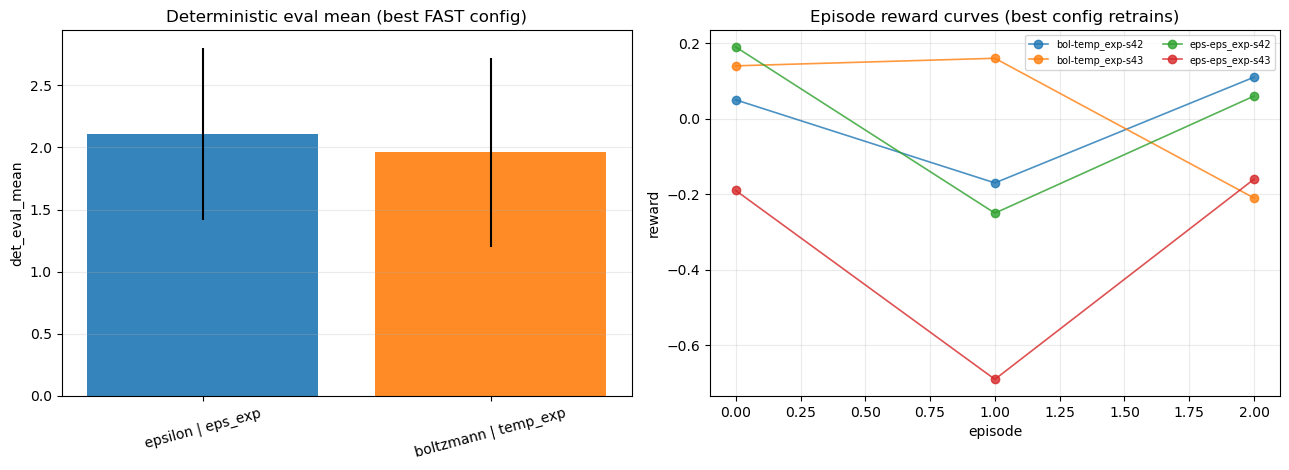

[ok] deterministic and learning-curve plots rendered


In [50]:
if "det_agg" not in globals() or det_agg is None or len(det_agg) == 0:
    print("Deterministic summary not found. Run the deterministic validation cell first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # Deterministic comparison
    x_labels = det_agg["strategy"] + " | " + det_agg["config"]
    axes[0].bar(
        x_labels,
        det_agg["det_eval_mean_across_seeds"],
        yerr=det_agg["det_eval_std_across_seeds"].fillna(0.0),
        color=["#1f77b4" if s == "epsilon" else "#ff7f0e" for s in det_agg["strategy"]],
        alpha=0.9,
    )
    axes[0].set_title("Deterministic eval mean (best FAST config)")
    axes[0].set_ylabel("det_eval_mean")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].grid(axis="y", alpha=0.25)

    # Training learning curves from stored best runs
    for (strategy_name, cfg_name, seed), run_data in detailed_best_runs.items():
        label = f"{strategy_name[:3]}-{cfg_name}-s{seed}"
        axes[1].plot(run_data["reward_hist"], marker="o", linewidth=1.2, alpha=0.8, label=label)
    axes[1].set_title("Episode reward curves (best config retrains)")
    axes[1].set_xlabel("episode")
    axes[1].set_ylabel("reward")
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()
    print("[ok] deterministic and learning-curve plots rendered")

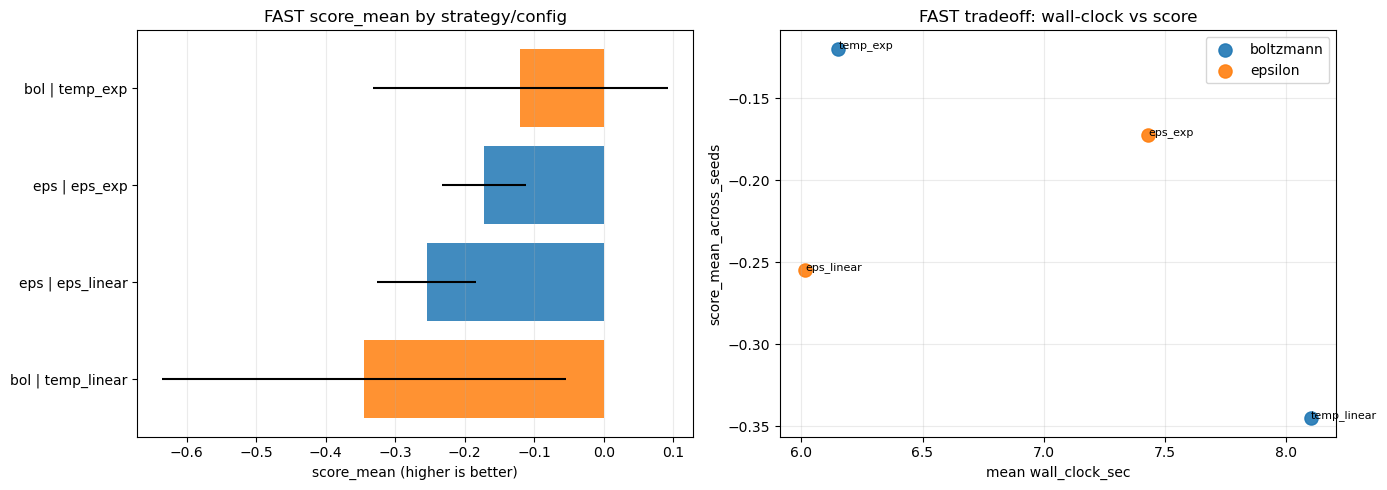

[ok] summary plots rendered


In [51]:
# Build aggregate tables if this cell is run before the table-builder cell
if "agg_cfg" not in globals() or agg_cfg is None or len(agg_cfg) == 0:
    df_all = show_results_table()
    assert df_all is not None and len(df_all) > 0, "No runs available in tracker"
    REPORT_COLS = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
    df_runs = df_all.reset_index()[["run_id"] + REPORT_COLS].copy()
    df_runs = df_runs.sort_values(["strategy", "config", "seed"]).reset_index(drop=True)
    agg_cfg = (
        df_runs.groupby(["strategy", "config"], as_index=False)
        .agg(
            score_mean_across_seeds=("score_mean", "mean"),
            score_std_across_seeds=("score_mean", "std"),
            score_min=("score_mean", "min"),
            score_max=("score_mean", "max"),
            wall_clock_mean=("wall_clock_sec", "mean"),
            n_seeds=("seed", "count"),
        )
        .sort_values(["strategy", "score_mean_across_seeds"], ascending=[True, False])
        .reset_index(drop=True)
    )

# Plot 1: per-config mean score with error bars
plot_df = agg_cfg.copy()
plot_df["label"] = plot_df["strategy"].str[:3] + " | " + plot_df["config"]
plot_df = plot_df.sort_values("score_mean_across_seeds", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    plot_df["label"],
    plot_df["score_mean_across_seeds"],
    xerr=plot_df["score_std_across_seeds"].fillna(0.0),
    color=["#1f77b4" if s == "epsilon" else "#ff7f0e" for s in plot_df["strategy"]],
    alpha=0.85,
)
axes[0].set_title("FAST score_mean by strategy/config")
axes[0].set_xlabel("score_mean (higher is better)")
axes[0].grid(axis="x", alpha=0.25)

# Plot 2: quality-cost tradeoff
for strategy_name, sub in agg_cfg.groupby("strategy"):
    axes[1].scatter(sub["wall_clock_mean"], sub["score_mean_across_seeds"], s=90, label=strategy_name, alpha=0.9)
    for _, row in sub.iterrows():
        axes[1].annotate(row["config"], (row["wall_clock_mean"], row["score_mean_across_seeds"]), fontsize=8)

axes[1].set_title("FAST tradeoff: wall-clock vs score")
axes[1].set_xlabel("mean wall_clock_sec")
axes[1].set_ylabel("score_mean_across_seeds")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()
print("[ok] summary plots rendered")

---
# 8. CSV Export Artifacts

Export FAST-mode tables for reporting and downstream analysis.

In [52]:
# Persist report artifacts (FAST mode) for easy inclusion in slides/report
ARTIFACT_FAST_RUNS = Path("task3_fast_runs_table.csv")
ARTIFACT_FAST_AGG = Path("task3_fast_agg_table.csv")
ARTIFACT_FAST_DET = Path("task3_fast_det_eval_table.csv")

if "df_runs" not in globals() or "agg_cfg" not in globals():
    df_all = show_results_table()
    assert df_all is not None and len(df_all) > 0, "No runs available in tracker"
    REPORT_COLS = ["strategy", "config", "seed", "score_mean", "score_std", "q_mean", "train_steps", "wall_clock_sec"]
    df_runs = df_all.reset_index()[["run_id"] + REPORT_COLS].copy()
    df_runs = df_runs.sort_values(["strategy", "config", "seed"]).reset_index(drop=True)
    agg_cfg = (
        df_runs.groupby(["strategy", "config"], as_index=False)
        .agg(
            score_mean_across_seeds=("score_mean", "mean"),
            score_std_across_seeds=("score_mean", "std"),
            score_min=("score_mean", "min"),
            score_max=("score_mean", "max"),
            wall_clock_mean=("wall_clock_sec", "mean"),
            n_seeds=("seed", "count"),
        )
        .sort_values(["strategy", "score_mean_across_seeds"], ascending=[True, False])
        .reset_index(drop=True)
    )

df_runs.to_csv(ARTIFACT_FAST_RUNS, index=False)
agg_cfg.to_csv(ARTIFACT_FAST_AGG, index=False)

if "df_det" in globals() and df_det is not None and len(df_det) > 0:
    df_det.to_csv(ARTIFACT_FAST_DET, index=False)
    det_msg = "saved"
else:
    det_msg = "skipped (run deterministic validation cell first)"

print("Saved FAST report artifacts:")
print(f"- {ARTIFACT_FAST_RUNS.resolve()}")
print(f"- {ARTIFACT_FAST_AGG.resolve()}")
print(f"- {ARTIFACT_FAST_DET.resolve()} -> {det_msg}")

assert ARTIFACT_FAST_RUNS.exists()
assert ARTIFACT_FAST_AGG.exists()
print("[ok] report artifact export complete")

Saved FAST report artifacts:
- C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2\tasks\task3_fast_runs_table.csv
- C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2\tasks\task3_fast_agg_table.csv
- C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj2\tasks\task3_fast_det_eval_table.csv -> saved
[ok] report artifact export complete


## 9. Final Notes

Notebook execution flow:
1. Setup and environment sanity checks.
2. Heuristic observability and deterministic baseline benchmarking.
3. Results tracking utilities.
4. Exploration components and shared DQN backbone.
5. FAST warm-start ablations and strategy smoke tests.
6. Epsilon and Boltzmann mini-grids.
7. Deterministic validation, plots, and artifact export.

Key consistency rules:
- keep backbone/preprocessing fixed across strategy comparisons,
- treat semantic channels as analysis-only (not DQN input),
- compare strategies under matched budgets and seed protocols.